In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# Purpose:
# - Load all dependencies required for the optimized ensemble decision layer
# - Keep project paths consistent with the corrected folder structure
# - Prepare plotting for later diagnostics
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 5.1 optimized ML dataset
# Purpose:
# - Load the optimized dataset containing raw data, optimized features, optimized targets,
#   optimized quant outputs, and optimized ML outputs
# - Preserve strict time order
# - Confirm the Phase 5.1 file contract before building the optimized ensemble layer
# ============================================

phase_5_1_parquet = PROCESSED_DIR / "phase_5_1_ml_data.parquet"
phase_5_1_csv = PROCESSED_DIR / "phase_5_1_ml_data.csv"

print("Looking for Phase 5.1 files:")
print("Parquet:", phase_5_1_parquet)
print("CSV:", phase_5_1_csv)

if phase_5_1_parquet.exists():
    df = pd.read_parquet(phase_5_1_parquet)
    print("Loaded Parquet file")
elif phase_5_1_csv.exists():
    df = pd.read_csv(phase_5_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 5.1 data file was not found. "
        f"Expected one of:\n{phase_5_1_parquet}\n{phase_5_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

Looking for Phase 5.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_data.csv
Loaded Parquet file

Dataset shape: (2770, 106)

Dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015-02-02 

In [3]:
# ============================================
# Cell 3: Validation before optimized ensemble construction
# Purpose:
# - Confirm that both the optimized quant and optimized ML layers are present
# - Fail early if required columns are missing
# - Prevent silent downstream errors in the optimized ensemble logic
# ============================================

required_cols = [
    "spy_close",
    "target_return_1d",
    "target_return_5d",
    "quant_signal",
    "quant_score",
    "quant_risk_filter",
    "quant_risk_score",
    "quant_regime_label_numeric",
    "ml_probability_mean",
    "ml_expected_return",
    "ml_signal",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Phase 6.1: {missing_cols}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

print("Phase 6.1 validation passed successfully.")

Phase 6.1 validation passed successfully.


In [4]:
# ============================================
# Cell 4: Helper functions for optimized ensemble logic
# Purpose:
# - Centralize ensemble scoring, confidence, and signal mapping
# - Keep the optimized decision process transparent and reproducible
# - Make the optimized layer easy to debug before optimized execution
# ============================================

def safe_min_max_scale(series: pd.Series) -> pd.Series:
    min_val = series.min()
    max_val = series.max()

    if pd.isna(min_val) or pd.isna(max_val):
        return pd.Series(np.nan, index=series.index)

    if max_val == min_val:
        scaled = pd.Series(0.5, index=series.index)
        scaled[series.isna()] = np.nan
        return scaled

    return (series - min_val) / (max_val - min_val)


def expanding_min_max_scale(series: pd.Series, min_periods: int = 60) -> pd.Series:
    exp_min = series.expanding(min_periods=min_periods).min()
    exp_max = series.expanding(min_periods=min_periods).max()

    out = pd.Series(np.nan, index=series.index, dtype=float)
    valid = exp_max > exp_min
    out.loc[valid] = (series.loc[valid] - exp_min.loc[valid]) / (exp_max.loc[valid] - exp_min.loc[valid])

    equal_mask = (exp_max == exp_min) & exp_min.notna()
    out.loc[equal_mask] = 0.5

    return out


def convert_regime_numeric_to_name(regime_numeric: pd.Series, full_df: pd.DataFrame) -> pd.Series:
    if "quant_regime_label" in full_df.columns:
        return full_df["quant_regime_label"].copy()

    out = pd.Series("unknown", index=regime_numeric.index, dtype="object")
    unique_labels = sorted(regime_numeric.dropna().unique().tolist())

    for label in unique_labels:
        out.loc[regime_numeric == label] = f"regime_{int(label)}"

    out.loc[regime_numeric.isna()] = np.nan
    return out


def build_ml_confidence(probability_mean: pd.Series, expected_return: pd.Series) -> pd.Series:
    prob_conf = (probability_mean - 0.5).abs() * 2.0
    return_mag = expanding_min_max_scale(expected_return.abs(), min_periods=60)
    confidence = 0.70 * prob_conf + 0.30 * return_mag
    return confidence.clip(lower=0.0, upper=1.0)


def build_quant_confidence(quant_score: pd.Series, risk_score: pd.Series) -> pd.Series:
    qs = expanding_min_max_scale(quant_score.abs(), min_periods=60)
    rs = 1.0 - risk_score.fillna(0.5)
    confidence = 0.70 * qs + 0.30 * rs
    return confidence.clip(lower=0.0, upper=1.0)


def map_ensemble_score_to_signal(score: pd.Series, buy_threshold: float, sell_threshold: float) -> pd.Series:
    signal = pd.Series(0, index=score.index, dtype=int)
    signal[score >= buy_threshold] = 1
    signal[score <= sell_threshold] = -1
    return signal


def map_signal_to_long_cash(signal: pd.Series) -> pd.Series:
    long_cash = pd.Series(0, index=signal.index, dtype=int)
    long_cash[signal == 1] = 1
    long_cash[signal <= 0] = 0
    return long_cash

In [5]:
# ============================================
# Cell 5: Build optimized ensemble input components
# Purpose:
# - Normalize optimized quant and optimized ML outputs into comparable components
# - Create interpretable sub-scores for direction, conviction, and risk
# - Prepare the final optimized ensemble decision rule
# ============================================

ensemble_df = df.copy()

ensemble_df["ensemble_regime_label"] = convert_regime_numeric_to_name(
    regime_numeric=ensemble_df["quant_regime_label_numeric"],
    full_df=ensemble_df,
)

# -----------------------------
# Quant components
# -----------------------------
ensemble_df["ensemble_quant_signal_component"] = ensemble_df["quant_signal"].fillna(0).astype(float)
ensemble_df["ensemble_quant_score_component"] = expanding_min_max_scale(
    ensemble_df["quant_score"],
    min_periods=60,
).fillna(0.5)
ensemble_df["ensemble_quant_centered_score"] = (ensemble_df["ensemble_quant_score_component"] - 0.5) * 2.0
ensemble_df["ensemble_quant_confidence"] = build_quant_confidence(
    quant_score=ensemble_df["quant_score"],
    risk_score=ensemble_df["quant_risk_score"],
).fillna(0.0)

# -----------------------------
# ML components
# -----------------------------
ensemble_df["ensemble_ml_probability_component"] = (ensemble_df["ml_probability_mean"].fillna(0.5) - 0.5) * 2.0
ensemble_df["ensemble_ml_expected_return_component"] = expanding_min_max_scale(
    ensemble_df["ml_expected_return"],
    min_periods=60,
).fillna(0.5)
ensemble_df["ensemble_ml_centered_return"] = (ensemble_df["ensemble_ml_expected_return_component"] - 0.5) * 2.0
ensemble_df["ensemble_ml_signal_component"] = ensemble_df["ml_signal"].fillna(0).astype(float)
ensemble_df["ensemble_ml_confidence"] = build_ml_confidence(
    probability_mean=ensemble_df["ml_probability_mean"],
    expected_return=ensemble_df["ml_expected_return"],
).fillna(0.0)

# -----------------------------
# Risk and gating components
# -----------------------------
ensemble_df["ensemble_risk_gate"] = ensemble_df["quant_risk_filter"].fillna(0).astype(int)
ensemble_df["ensemble_risk_penalty"] = ensemble_df["quant_risk_score"].fillna(0.5)

print("Optimized ensemble inputs created.")
print(
    ensemble_df[
        [
            "ensemble_quant_signal_component",
            "ensemble_quant_centered_score",
            "ensemble_quant_confidence",
            "ensemble_ml_probability_component",
            "ensemble_ml_centered_return",
            "ensemble_ml_confidence",
            "ensemble_risk_gate",
        ]
    ].head()
)

Optimized ensemble inputs created.
            ensemble_quant_signal_component  ensemble_quant_centered_score  \
Date                                                                         
2015-02-02                              0.0                            0.0   
2015-02-03                              0.0                            0.0   
2015-02-04                              0.0                            0.0   
2015-02-05                              0.0                            0.0   
2015-02-06                              0.0                            0.0   

            ensemble_quant_confidence  ensemble_ml_probability_component  \
Date                                                                       
2015-02-02                        0.0                                0.0   
2015-02-03                        0.0                                0.0   
2015-02-04                        0.0                                0.0   
2015-02-05                        0.0 

In [6]:
# ============================================
# Cell 6: Optimized regime-aware weighting logic for return capture
# Purpose:
# - Shift the ensemble toward stronger long participation
# - Favor quant trend structure heavily in trending markets
# - Reduce excessive hesitation in constructive conditions
# ============================================

ensemble_df["ensemble_weight_quant"] = 0.50
ensemble_df["ensemble_weight_ml"] = 0.50

regime_label = ensemble_df["ensemble_regime_label"].astype("object")

# Stronger long-bias architecture
ensemble_df.loc[regime_label == "trending", "ensemble_weight_quant"] = 0.65
ensemble_df.loc[regime_label == "trending", "ensemble_weight_ml"] = 0.35

ensemble_df.loc[regime_label == "mean_reverting", "ensemble_weight_quant"] = 0.45
ensemble_df.loc[regime_label == "mean_reverting", "ensemble_weight_ml"] = 0.55

ensemble_df.loc[regime_label == "transition", "ensemble_weight_quant"] = 0.55
ensemble_df.loc[regime_label == "transition", "ensemble_weight_ml"] = 0.45

ensemble_df.loc[regime_label == "high_volatility", "ensemble_weight_quant"] = 0.70
ensemble_df.loc[regime_label == "high_volatility", "ensemble_weight_ml"] = 0.30

print("Optimized regime-aware return-capture weights assigned.")
print(
    ensemble_df[
        [
            "ensemble_regime_label",
            "ensemble_weight_quant",
            "ensemble_weight_ml",
        ]
    ].head(10)
)

Optimized regime-aware return-capture weights assigned.
           ensemble_regime_label  ensemble_weight_quant  ensemble_weight_ml
Date                                                                       
2015-02-02        mean_reverting                   0.45                0.55
2015-02-03        mean_reverting                   0.45                0.55
2015-02-04              trending                   0.65                0.35
2015-02-05        mean_reverting                   0.45                0.55
2015-02-06              trending                   0.65                0.35
2015-02-09              trending                   0.65                0.35
2015-02-10              trending                   0.65                0.35
2015-02-11              trending                   0.65                0.35
2015-02-12              trending                   0.65                0.35
2015-02-13              trending                   0.65                0.35


In [7]:
# ============================================
# Cell 7: Build the optimized continuous ensemble score for return capture
# Purpose:
# - Make the ensemble more persistent and pro-trend
# - Reduce over-penalization that was suppressing exposure
# - Keep risk-aware logic, but stop crushing upside participation
# ============================================

# Quant sub-score
ensemble_df["ensemble_quant_subscore"] = (
    0.40 * ensemble_df["ensemble_quant_signal_component"] +
    0.60 * ensemble_df["ensemble_quant_centered_score"]
)

ensemble_df["ensemble_quant_conf_adj_subscore"] = (
    ensemble_df["ensemble_quant_subscore"] * (0.70 + 0.30 * ensemble_df["ensemble_quant_confidence"])
)

# ML sub-score
ensemble_df["ensemble_ml_subscore"] = (
    0.40 * ensemble_df["ensemble_ml_probability_component"] +
    0.35 * ensemble_df["ensemble_ml_centered_return"] +
    0.25 * ensemble_df["ensemble_ml_signal_component"]
)

ensemble_df["ensemble_ml_conf_adj_subscore"] = (
    ensemble_df["ensemble_ml_subscore"] * (0.65 + 0.35 * ensemble_df["ensemble_ml_confidence"])
)

# Base raw score
ensemble_df["ensemble_score_raw"] = (
    ensemble_df["ensemble_weight_quant"] * ensemble_df["ensemble_quant_conf_adj_subscore"] +
    ensemble_df["ensemble_weight_ml"] * ensemble_df["ensemble_ml_conf_adj_subscore"]
)

# Trend-persistence boost:
# if regime is trending and quant is already constructive, bias the score upward
ensemble_df["ensemble_trend_boost"] = 0.0
ensemble_df.loc[
    (ensemble_df["ensemble_regime_label"] == "trending") &
    (ensemble_df["quant_signal"] == 1),
    "ensemble_trend_boost"
] = 0.08

ensemble_df.loc[
    (ensemble_df["ensemble_regime_label"] == "transition") &
    (ensemble_df["quant_signal"] == 1),
    "ensemble_trend_boost"
] = 0.04

# Regime penalty: lighter than before
ensemble_df["ensemble_regime_penalty"] = 0.0
ensemble_df.loc[ensemble_df["ensemble_regime_label"] == "high_volatility", "ensemble_regime_penalty"] = 0.08
ensemble_df.loc[ensemble_df["ensemble_regime_label"] == "transition", "ensemble_regime_penalty"] = 0.01

# Risk penalty: reduced so it does not constantly suppress long exposure
ensemble_df["ensemble_score_after_penalty"] = (
    ensemble_df["ensemble_score_raw"] +
    ensemble_df["ensemble_trend_boost"] -
    ensemble_df["ensemble_regime_penalty"] -
    (ensemble_df["ensemble_risk_penalty"] - 0.5) * 0.10
)

# Final gate:
# if risk gate is off, do not force a large negative score; just neutralize
ensemble_df["ensemble_score"] = np.where(
    ensemble_df["ensemble_risk_gate"] == 1,
    ensemble_df["ensemble_score_after_penalty"],
    0.02
)

print("Optimized return-capture ensemble score created.")
print(
    ensemble_df[
        [
            "ensemble_quant_subscore",
            "ensemble_quant_conf_adj_subscore",
            "ensemble_ml_subscore",
            "ensemble_ml_conf_adj_subscore",
            "ensemble_score_raw",
            "ensemble_trend_boost",
            "ensemble_score",
        ]
    ].head()
)

Optimized return-capture ensemble score created.
            ensemble_quant_subscore  ensemble_quant_conf_adj_subscore  \
Date                                                                    
2015-02-02                      0.0                               0.0   
2015-02-03                      0.0                               0.0   
2015-02-04                      0.0                               0.0   
2015-02-05                      0.0                               0.0   
2015-02-06                      0.0                               0.0   

            ensemble_ml_subscore  ensemble_ml_conf_adj_subscore  \
Date                                                              
2015-02-02                   0.0                            0.0   
2015-02-03                   0.0                            0.0   
2015-02-04                   0.0                            0.0   
2015-02-05                   0.0                            0.0   
2015-02-06                   0.0     

In [8]:
# ============================================
# Cell 8: Threshold search for optimized ensemble decisions
# Purpose:
# - Lower the buy threshold to increase participation
# - Make sell thresholds stricter so cash exits are rarer
# - Favor return capture over excessive caution
# ============================================

evaluation_mask = (
    (ensemble_df.index >= pd.Timestamp("2020-01-01")) &
    (ensemble_df.index <= pd.Timestamp(TRAIN_END))
)

threshold_grid = [
    (0.04, -0.18),
    (0.06, -0.20),
    (0.08, -0.22),
    (0.10, -0.25),
]

threshold_rows = []

for buy_th, sell_th in threshold_grid:
    temp_signal = map_ensemble_score_to_signal(
        score=ensemble_df["ensemble_score"],
        buy_threshold=buy_th,
        sell_threshold=sell_th,
    )

    temp_eval = pd.DataFrame({
        "signal": temp_signal,
        "target_return_5d": ensemble_df["target_return_5d"],
    }).loc[evaluation_mask].dropna()

    active = temp_eval["signal"] != 0

    if active.sum() == 0:
        hit_rate = np.nan
        activity_rate = 0.0
    else:
        hit_rate = float(
            (
                ((temp_eval.loc[active, "signal"] == 1) & (temp_eval.loc[active, "target_return_5d"] > 0)) |
                ((temp_eval.loc[active, "signal"] == -1) & (temp_eval.loc[active, "target_return_5d"] < 0))
            ).mean()
        )
        activity_rate = float((temp_eval["signal"] == 1).mean())

    threshold_rows.append({
        "buy_threshold": buy_th,
        "sell_threshold": sell_th,
        "activity_rate": activity_rate,
        "directional_hit_rate": hit_rate,
    })

threshold_eval_df = pd.DataFrame(threshold_rows).sort_values(
    ["directional_hit_rate", "activity_rate"],
    ascending=[False, False]
).reset_index(drop=True)

BEST_BUY_THRESHOLD = float(threshold_eval_df.loc[0, "buy_threshold"])
BEST_SELL_THRESHOLD = float(threshold_eval_df.loc[0, "sell_threshold"])

print("Optimized return-capture threshold evaluation:")
print(threshold_eval_df)

print("\nChosen thresholds:")
print("BEST_BUY_THRESHOLD =", BEST_BUY_THRESHOLD)
print("BEST_SELL_THRESHOLD =", BEST_SELL_THRESHOLD)

Optimized return-capture threshold evaluation:
   buy_threshold  sell_threshold  activity_rate  directional_hit_rate
0           0.10           -0.25       0.558824              0.736041
1           0.08           -0.22       0.574722              0.729397
2           0.06           -0.20       0.599364              0.714959
3           0.04           -0.18       0.612083              0.711494

Chosen thresholds:
BEST_BUY_THRESHOLD = 0.1
BEST_SELL_THRESHOLD = -0.25


In [9]:
# ============================================
# Cell 9: Map optimized ensemble score into return-capture decisions
# Purpose:
# - Convert the optimized score into Buy, Hold, and Sell decisions
# - Replace the hard alpha filter with a soft alpha + ranking approach
# - Keep the system invested in constructive regimes
# - Improve return capture while still favoring stronger opportunities
# ============================================

# --------------------------------------------
# Base signal mapping from ensemble score
# --------------------------------------------
ensemble_df["ensemble_signal_general"] = map_ensemble_score_to_signal(
    score=ensemble_df["ensemble_score"],
    buy_threshold=BEST_BUY_THRESHOLD,
    sell_threshold=BEST_SELL_THRESHOLD,
)

# --------------------------------------------
# Soft alpha + ranking layer
# Purpose:
# - Rank expected returns over a rolling 252-day window
# - Reduce weak signals instead of killing everything
# - Boost strong signals to improve return capture
# --------------------------------------------
ensemble_df["ml_return_rank"] = (
    ensemble_df["ml_expected_return"]
    .rolling(252)
    .apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] if len(x) > 0 else np.nan,
        raw=False
    )
)

ensemble_df["alpha_strength"] = ensemble_df["ml_return_rank"].fillna(0.5)

# Weak alpha: neutralize weak opportunities
ensemble_df.loc[
    ensemble_df["alpha_strength"] < 0.40,
    "ensemble_signal_general"
] = 0

# Strong alpha: promote to buy
ensemble_df.loc[
    ensemble_df["alpha_strength"] > 0.70,
    "ensemble_signal_general"
] = 1

# --------------------------------------------
# Constructive regime persistence
# Purpose:
# - In trending and transition regimes, do not sit out mild positive environments
# - This is critical for improving bull-market participation
# --------------------------------------------
constructive_mask = ensemble_df["ensemble_regime_label"].isin(["trending", "transition"])

ensemble_df.loc[
    constructive_mask &
    (ensemble_df["ensemble_signal_general"] == 0) &
    (ensemble_df["ensemble_score"] > 0.02),
    "ensemble_signal_general"
] = 1

# Extra long-bias persistence in clear trending regimes
ensemble_df.loc[
    (ensemble_df["ensemble_regime_label"] == "trending") &
    (ensemble_df["ensemble_signal_general"] == 0),
    "ensemble_signal_general"
] = 1

# --------------------------------------------
# Final mapping to long/cash implementation
# --------------------------------------------
ensemble_df["ensemble_signal"] = map_signal_to_long_cash(ensemble_df["ensemble_signal_general"])
ensemble_df["ensemble_confidence"] = ensemble_df["ensemble_score"].abs().clip(lower=0.0, upper=1.0)

print("Optimized return-capture ensemble decisions created.")
print(
    ensemble_df[
        [
            "ensemble_score",
            "ml_expected_return",
            "ml_return_rank",
            "alpha_strength",
            "ensemble_signal_general",
            "ensemble_signal",
            "ensemble_confidence",
        ]
    ].head(20)
)

Optimized return-capture ensemble decisions created.
            ensemble_score  ml_expected_return  ml_return_rank  \
Date                                                             
2015-02-02            0.02                 NaN             NaN   
2015-02-03            0.02                 NaN             NaN   
2015-02-04            0.02                 NaN             NaN   
2015-02-05            0.02                 NaN             NaN   
2015-02-06            0.02                 NaN             NaN   
2015-02-09            0.02                 NaN             NaN   
2015-02-10            0.02                 NaN             NaN   
2015-02-11            0.02                 NaN             NaN   
2015-02-12            0.02                 NaN             NaN   
2015-02-13            0.02                 NaN             NaN   
2015-02-17            0.02                 NaN             NaN   
2015-02-18            0.02                 NaN             NaN   
2015-02-19            0

In [10]:
# ============================================
# Cell 10: Diagnostic evaluation of the optimized ensemble layer
# Purpose:
# - Evaluate the optimized decision layer before execution and position sizing
# - Compare optimized ensemble output against optimized quant and buy-and-hold baselines
# - Keep this evaluation simple and directional rather than full portfolio-level
# ============================================

ensemble_eval = ensemble_df.copy()

ensemble_eval["ensemble_position_next_day"] = ensemble_eval["ensemble_signal"].shift(1).fillna(0)
ensemble_eval["ensemble_strategy_return_1d"] = (
    ensemble_eval["ensemble_position_next_day"] * ensemble_eval["target_return_1d"]
)

ensemble_eval["quant_position_next_day"] = ensemble_eval["quant_signal"].shift(1).fillna(0)
ensemble_eval["quant_strategy_return_1d"] = (
    ensemble_eval["quant_position_next_day"] * ensemble_eval["target_return_1d"]
)

ensemble_eval["buy_hold_return_1d"] = ensemble_eval["target_return_1d"]

ensemble_eval["ensemble_equity_curve"] = (1.0 + ensemble_eval["ensemble_strategy_return_1d"].fillna(0.0)).cumprod()
ensemble_eval["quant_equity_curve"] = (1.0 + ensemble_eval["quant_strategy_return_1d"].fillna(0.0)).cumprod()
ensemble_eval["buy_hold_equity_curve"] = (1.0 + ensemble_eval["buy_hold_return_1d"].fillna(0.0)).cumprod()

ensemble_active_days = int((ensemble_eval["ensemble_signal"] != 0).sum())
ensemble_exposure_rate = float((ensemble_eval["ensemble_position_next_day"] > 0).mean())

ensemble_hit_rate = float(
    (
        ensemble_eval.loc[ensemble_eval["ensemble_position_next_day"] > 0, "target_return_5d"] > 0
    ).mean()
) if (ensemble_eval["ensemble_position_next_day"] > 0).sum() > 0 else np.nan

print("Optimized ensemble signal diagnostics")
print("------------------------------------")
print("Active signal days:", ensemble_active_days)
print("Exposure rate:", round(ensemble_exposure_rate, 4))
print("Directional 5-day hit rate:", round(ensemble_hit_rate, 4) if pd.notna(ensemble_hit_rate) else np.nan)

print("\nFinal equity values")
print("Optimized ensemble baseline:", round(float(ensemble_eval["ensemble_equity_curve"].iloc[-1]), 4))
print("Optimized quant baseline:", round(float(ensemble_eval["quant_equity_curve"].iloc[-1]), 4))
print("Buy and hold:", round(float(ensemble_eval["buy_hold_equity_curve"].iloc[-1]), 4))

Optimized ensemble signal diagnostics
------------------------------------
Active signal days: 1744
Exposure rate: 0.6292
Directional 5-day hit rate: 0.6437

Final equity values
Optimized ensemble baseline: 3.4416
Optimized quant baseline: 1.5099
Buy and hold: 3.4203


In [11]:
# ============================================
# Cell 11: Regime-by-signal summary for the optimized ensemble layer
# Purpose:
# - Check whether the optimized ensemble behaves differently across regimes
# - Confirm that regime-aware logic is active and meaningful
# - Create a compact diagnostic table for later interpretation
# ============================================

regime_signal_summary = (
    ensemble_df.groupby("ensemble_regime_label")
    .agg(
        rows=("ensemble_signal", "size"),
        buy_signals=("ensemble_signal", "sum"),
        avg_score=("ensemble_score", "mean"),
        avg_confidence=("ensemble_confidence", "mean"),
        avg_ml_probability=("ml_probability_mean", "mean"),
        avg_quant_score=("quant_score", "mean"),
        avg_target_return_5d=("target_return_5d", "mean"),
    )
    .sort_values("rows", ascending=False)
)

print("Optimized signal distribution by regime:")
print(regime_signal_summary)

Optimized signal distribution by regime:
                       rows  buy_signals  avg_score  avg_confidence  \
ensemble_regime_label                                                 
trending               1450         1446   0.291204        0.305791   
mean_reverting         1128          199   0.031617        0.110291   
transition              120           89   0.265411        0.311822   
high_volatility          72           10  -0.009918        0.079976   

                       avg_ml_probability  avg_quant_score  \
ensemble_regime_label                                        
trending                         0.465617        -0.079510   
mean_reverting                   0.534801        -0.181778   
transition                       0.685747        -0.027780   
high_volatility                  0.661261        -0.439149   

                       avg_target_return_5d  
ensemble_regime_label                        
trending                           0.001433  
mean_reverting       

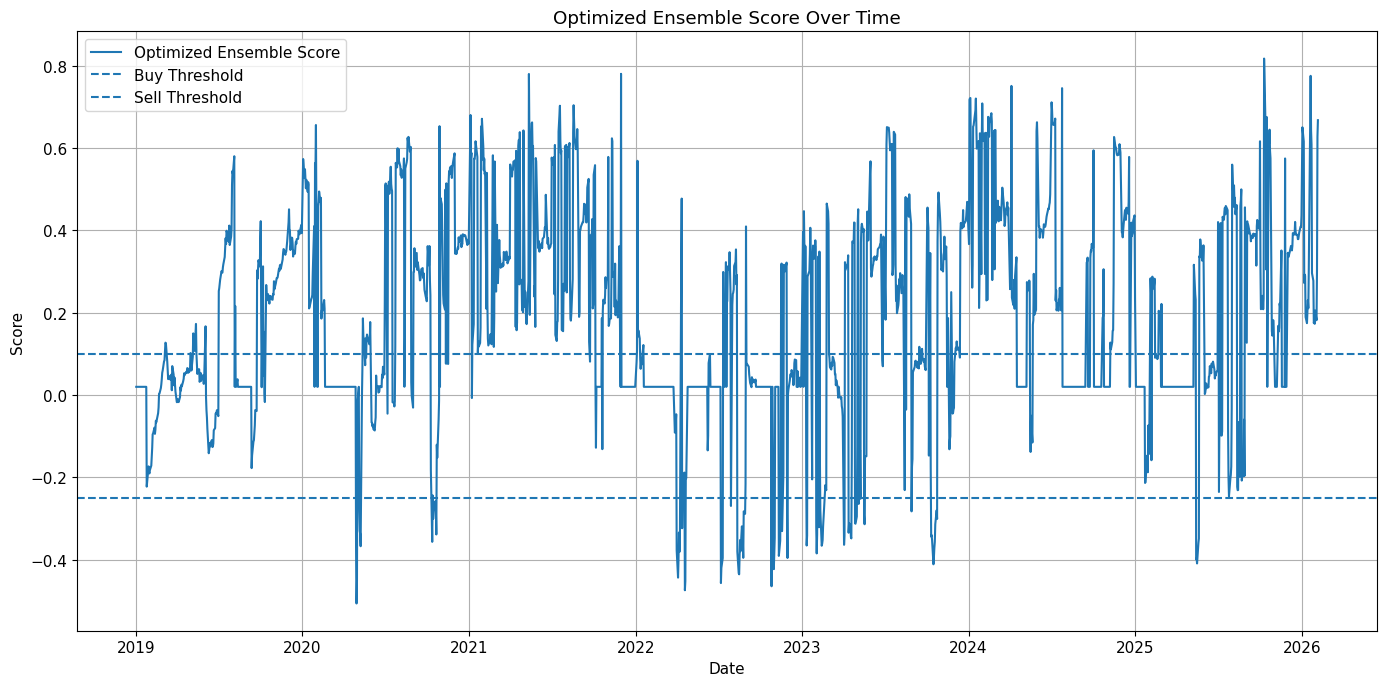

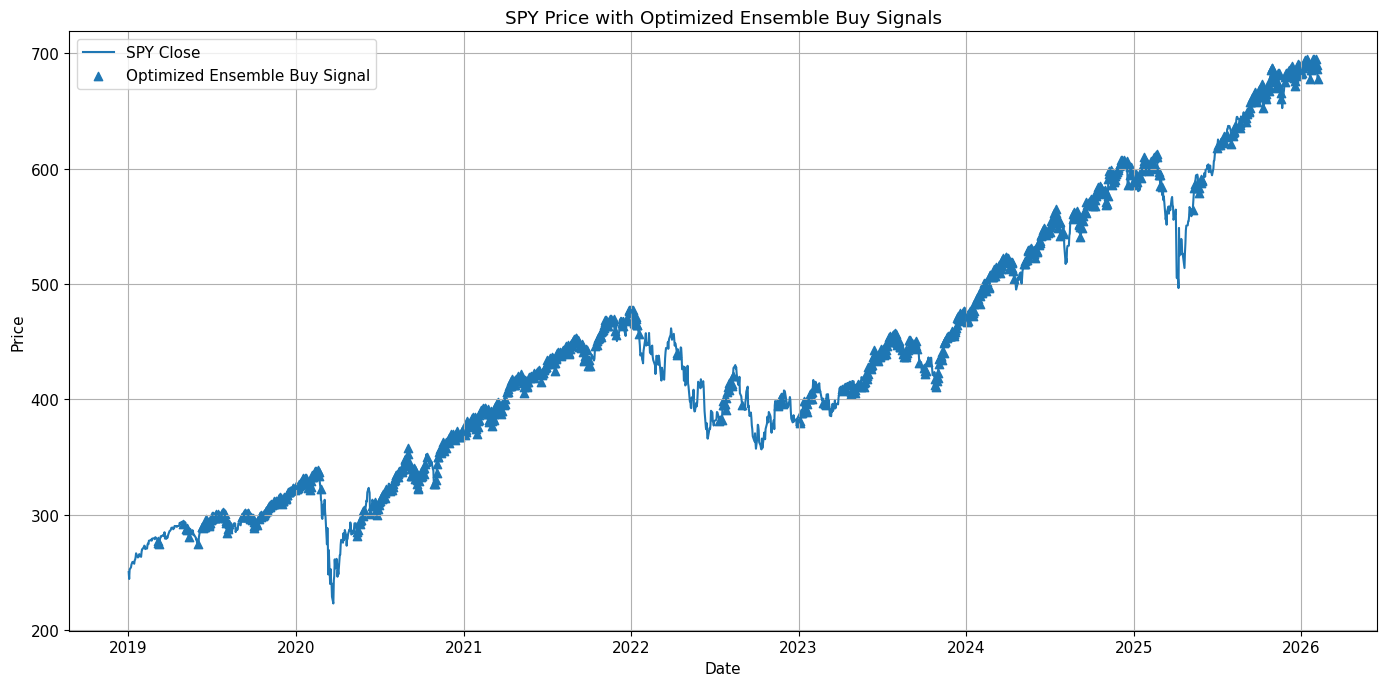

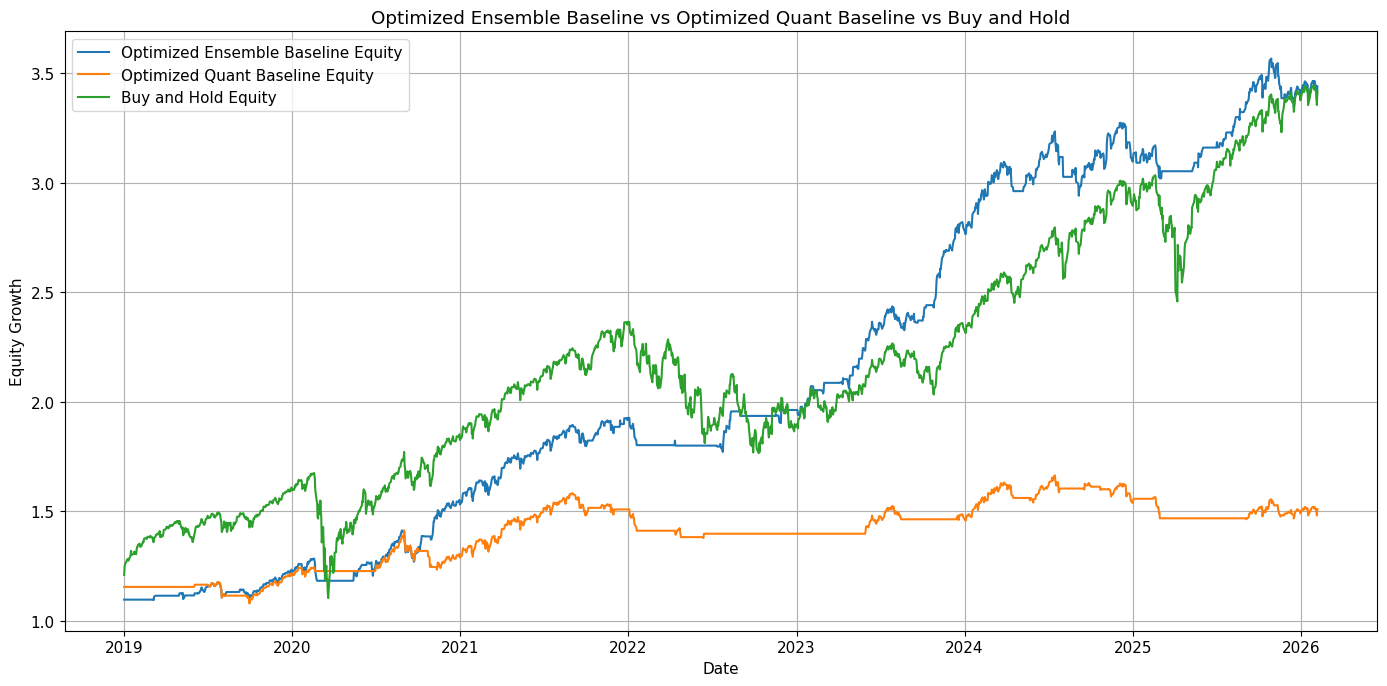

In [12]:
# ============================================
# Cell 12: Visualization of optimized ensemble scores, signals, and equity
# Purpose:
# - Visually inspect whether the optimized ensemble behaves sensibly over time
# - Compare optimized ensemble output to optimized quant and buy-and-hold baselines
# - Save formal figures for later reporting
# ============================================

plot_data = ensemble_df.loc["2019-01-01":].copy()
plot_eval = ensemble_eval.loc["2019-01-01":].copy()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["ensemble_score"], label="Optimized Ensemble Score")
ax.axhline(BEST_BUY_THRESHOLD, linestyle="--", label="Buy Threshold")
ax.axhline(BEST_SELL_THRESHOLD, linestyle="--", label="Sell Threshold")
ax.set_title("Optimized Ensemble Score Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Score")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_6_1_ensemble_score.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["spy_close"], label="SPY Close")
ax.scatter(
    plot_data.index[plot_data["ensemble_signal"] == 1],
    plot_data.loc[plot_data["ensemble_signal"] == 1, "spy_close"],
    label="Optimized Ensemble Buy Signal",
    marker="^",
)
ax.set_title("SPY Price with Optimized Ensemble Buy Signals")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_6_1_ensemble_buy_signals.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_eval.index, plot_eval["ensemble_equity_curve"], label="Optimized Ensemble Baseline Equity")
ax.plot(plot_eval.index, plot_eval["quant_equity_curve"], label="Optimized Quant Baseline Equity")
ax.plot(plot_eval.index, plot_eval["buy_hold_equity_curve"], label="Buy and Hold Equity")
ax.set_title("Optimized Ensemble Baseline vs Optimized Quant Baseline vs Buy and Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity Growth")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_6_1_ensemble_vs_baselines.png", dpi=150)
plt.show()

In [13]:
# ============================================
# Cell 13: Save Phase 6.1 outputs for Phase 7.1
# Purpose:
# - Persist the optimized ensemble decision layer outputs
# - Save metadata and diagnostics for later review
# - Maintain a stable notebook-to-notebook contract
# ============================================

phase_6_1_csv_path = PROCESSED_DIR / "phase_6_1_ensemble_data.csv"
phase_6_1_parquet_path = PROCESSED_DIR / "phase_6_1_ensemble_data.parquet"
phase_6_1_regime_summary_csv_path = PROCESSED_DIR / "phase_6_1_regime_signal_summary.csv"
phase_6_1_threshold_csv_path = PROCESSED_DIR / "phase_6_1_threshold_eval.csv"

ensemble_df.to_csv(phase_6_1_csv_path, index=True)
print(f"Saved CSV: {phase_6_1_csv_path}")

try:
    ensemble_df.to_parquet(phase_6_1_parquet_path, index=True)
    print(f"Saved Parquet: {phase_6_1_parquet_path}")
except Exception as e:
    print(f"Parquet save skipped: {e}")

regime_signal_summary.to_csv(phase_6_1_regime_summary_csv_path, index=True)
print(f"Saved regime summary CSV: {phase_6_1_regime_summary_csv_path}")

threshold_eval_df.to_csv(phase_6_1_threshold_csv_path, index=False)
print(f"Saved threshold evaluation CSV: {phase_6_1_threshold_csv_path}")

phase_6_1_metadata = {
    "phase": "Phase 6.1 - Ensemble Decision Layer (Optimized)",
    "source_notebook": "6.1 - Ensemble Decision Layer (Optimized).ipynb",
    "row_count": int(len(ensemble_df)),
    "column_count": int(ensemble_df.shape[1]),
    "buy_threshold": float(BEST_BUY_THRESHOLD),
    "sell_threshold": float(BEST_SELL_THRESHOLD),
    "ensemble_signal_distribution": {
        str(k): int(v) for k, v in ensemble_df["ensemble_signal"].value_counts(dropna=False).to_dict().items()
    },
    "ensemble_general_signal_distribution": {
        str(k): int(v) for k, v in ensemble_df["ensemble_signal_general"].value_counts(dropna=False).to_dict().items()
    },
    "start_date": str(ensemble_df.index.min().date()),
    "end_date": str(ensemble_df.index.max().date()),
}

phase_6_1_metadata_path = META_DIR / "phase_6_1_metadata.json"
with open(phase_6_1_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_6_1_metadata, f, indent=4)

print(f"Saved metadata: {phase_6_1_metadata_path}")
print("Phase 6.1 output contract is ready for Phase 7.1.")

Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_ensemble_data.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_ensemble_data.parquet
Saved regime summary CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_regime_signal_summary.csv
Saved threshold evaluation CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_threshold_eval.csv
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_6_1_metadata.json
Phase 6.1 output contract is ready for Phase 7.1.


In [14]:
# ============================================
# Cell 14: Phase 7.1 loader snippet
# Purpose:
# - Provide a stable loading pattern for the optimized execution and risk management notebook
# - Keep notebook integration deterministic and easy to debug
# - Confirm the optimized ensemble handoff works
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

phase_6_1_parquet = PROCESSED_DIR / "phase_6_1_ensemble_data.parquet"
phase_6_1_csv = PROCESSED_DIR / "phase_6_1_ensemble_data.csv"

print("Looking for Phase 6.1 files:")
print("Parquet:", phase_6_1_parquet)
print("CSV:", phase_6_1_csv)

if phase_6_1_parquet.exists():
    phase_6_1_data = pd.read_parquet(phase_6_1_parquet)
    print("Loaded Parquet file")
elif phase_6_1_csv.exists():
    phase_6_1_data = pd.read_csv(phase_6_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 6.1 data file was not found. "
        f"Expected one of:\n{phase_6_1_parquet}\n{phase_6_1_csv}"
    )

phase_6_1_data.index = pd.to_datetime(phase_6_1_data.index)
phase_6_1_data = phase_6_1_data.sort_index()

print("\nLoaded Phase 6.1 dataset preview:")
print(phase_6_1_data.head())

Looking for Phase 6.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_ensemble_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_ensemble_data.csv
Loaded Parquet file

Loaded Phase 6.1 dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015-02-02